In [2]:
import pandas as pd # load and manipulate data and for One-Hot Encoding
import numpy as np # calculate the mean and standard deviation
import matplotlib.pyplot as plt # drawing graphs
from sklearn.tree import DecisionTreeClassifier # a classification tree
from sklearn.tree import plot_tree # draw a classification tree
from sklearn.model_selection import train_test_split # split  data into training and testing sets
from sklearn.model_selection import cross_val_score # cross validation
from sklearn.metrics import ConfusionMatrixDisplay # creates a confusion matrix
#from sklearn.metrics import plot_confusion_matrix # draws a confusion matrix

# Importar dados

Conjunto de dados **Heart Disease** da UCI Machine Learning Repository, disponível em https://doi.org/10.24432/C52P4X
Com base nesse conjunto de dados, podemos prever se uma pessoa tem doença cardíaca a partir do sexo, da idade, da pressão arterial e de uma série de outros parâmetros.

In [3]:
df = pd.read_csv("data/processed_cleveland.data", header=None)

In [4]:
# Exibir as primeiras linhas do DataFrame para verificar os dados
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Como nomes de colunas descritivos facilitariam a compreensão de como formatar os dados, vamos substituir os números de colunas pelos seguintes nomes:
- age,
- sex,
- cp, dor no peito
- restbp, pressão arterial em repouso (em mm Hg)
- chol, colesterol sérico em mg/dl
- fbs, glicemia em jejum
- restecg, resultados eletrocardiográficos em repouso
- thalach, frequência cardíaca máxima alcançada
- exang, angina induzida por exercício
- oldpeak, depressão do segmento ST induzida pelo exercício em relação ao repouso
- slope, a inclinação do segmento ST no pico do exercício.
- ca, número de vasos principais (0-3) coloridos por fluoroscopia
- thal, abreviação de cintilografia cardíaca com tálio.
- hd, diagnóstico de doença cardíaca, o atributo previsto

In [5]:
# Atribuir nomes às colunas do DataFrame
df.columns = ['age', 
              'sex', 
              'cp', 
              'restbp', 
              'chol', 
              'fbs', 
              'restecg', 
              'thalach', 
              'exang', 
              'oldpeak', 
              'slope', 
              'ca', 
              'thal', 
              'hd']
df.head()

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Identificação de dados ausentes

In [6]:
df.dtypes

age        float64
sex        float64
cp         float64
restbp     float64
chol       float64
fbs        float64
restecg    float64
thalach    float64
exang      float64
oldpeak    float64
slope      float64
ca             str
thal           str
hd           int64
dtype: object

Os tipos de dados `object` são usados quando há misturas de elementos, como uma mistura de números e letras.

In [7]:
# Identificar os valores únicos na coluna 'ca' para verificar a presença de valores não numéricos
df['ca'].unique()

<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str

Vemos que **ca** contém números (0,0, 3,0, 2,0 e 1,0) e pontos de interrogação. Os números representam o número de vasos sanguíneos que iluminamos por fluoroscopia e os pontos de interrogação representam dados ausentes.

In [8]:
# Identificar os valores únicos na coluna 'thal' para verificar a presença de valores não numéricos
df['thal'].unique()

<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str

Como as árvores de classificação do scikit-learn não suportam conjuntos de dados com valores ausentes, precisamos decidir o que fazer com esses valores em branco.

In [9]:
# Contar o número de linhas que possuem valores não numéricos nas colunas 'ca' e 'thal'
len(df.loc[(df['ca'] == '?') | (df['thal'] == '?')])

6

In [10]:
# Exibir o número total de linhas no DataFrame para entender a proporção de dados com valores não numéricos
len(df)

303

In [11]:
# Criar um novo DataFrame que exclui as linhas com valores não numéricos nas colunas 'ca' e 'thal'
df_no_missing = df.loc[(df['ca'] != '?') & (df['thal'] != '?')]
len(df_no_missing)

297

In [12]:
# Verificar os valores únicos na coluna 'ca' do novo DataFrame para confirmar que os valores não numéricos foram removidos
df_no_missing['ca'].unique()

<StringArray>
['0.0', '3.0', '2.0', '1.0']
Length: 4, dtype: str

In [13]:
# Verificar os valores únicos na coluna 'thal' do novo DataFrame para confirmar que os valores não numéricos foram removidos
df_no_missing['thal'].unique()

<StringArray>
['6.0', '3.0', '7.0']
Length: 3, dtype: str

# Dividisão dos dados em variáveis dependentes e independentes

O primeiro passo é dividir os dados em duas partes:
- As colunas de dados que usaremos para fazer as classificações
- A coluna de dados que queremos prever.

In [14]:
X = df_no_missing.drop('hd', axis=1).copy() # Criar uma cópia do DataFrame sem a coluna 'hd'
X.head()

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


O uso de `copy()` garante que os dados originais `df_no_missing` não sejam alterados quando modificamos `X` ou `y`. Em outras palavras, se cometermos um erro ao formatar as colunas para as árvores de classificação, basta copiar novamente `df_no_missing`, em vez de ter que recarregar os dados originais e remover os valores ausentes, etc.

In [15]:
y = df_no_missing['hd'].copy()              # Separar a coluna 'hd' como variável alvo (y)
y.head()

0    0
1    2
2    1
3    0
4    0
Name: hd, dtype: int64

A lista abaixo indica o que cada variável representa e o tipo de dados (**float** ou **categórico**) que deve conter:

- **idade**, **float**
- **sexo** - **categórico**
  - 0 = mulher
  - 1 = homem
- **cp**, dor no peito, **categórico**
  - 1 = angina típica,
  - 2 = angina atípica,
  - 3 = dor não anginosa,
  - 4 = assintomático
- **restbp**, pressão arterial em repouso (em mm Hg), **Float**
- **chol**, colesterol sérico em mg/dl, **Float**
- **fbs**, glicemia em jejum, **Categoria**
  - 0 = >=120 mg/dl
  - 1 = <120 mg/dl
- **restecg**, resultados do eletrocardiograma em repouso, **Categoria**
  - 1 = normal
  - 2 = com anormalidade da onda ST-T
  - 3 = indicando hipertrofia ventricular esquerda provável ou definitiva
- **thalach**, frequência cardíaca máxima alcançada, **Float**
- **exang**, angina induzida por exercício, **Categoria**
  - 0 = não
  - 1 = sim
- **oldpeak**, depressão do segmento ST induzida pelo exercício em relação ao repouso. **Float**
- **slope**, a inclinação do segmento ST no pico do exercício, **Categoria**
  - 1 = ascendente
  - 2 = plano
  - 3 = descendente
- **ca**, número de vasos principais (0-3) visualizados por fluoroscopia, **Float**
- **thal**, cintilografia cardíaca com tálio, **Categoria**
  - 3 = normal (sem pontos frios)
  - 6 = defeito fixo (pontos frios durante o repouso e o exercício)
  - 7 = defeito reversível (quando os pontos frios aparecem apenas durante o exercício)

In [16]:
X.dtypes

age        float64
sex        float64
cp         float64
restbp     float64
chol       float64
fbs        float64
restecg    float64
thalach    float64
exang      float64
oldpeak    float64
slope      float64
ca             str
thal           str
dtype: object

Vemos que **age**, **restbp**, **chol** e **thalach** são todos do tipo `float64`. Embora o **scikit-learn Decision Trees** ofereça suporte nativo a dados contínuos, como pressão arterial em repouso (**restbp**) e frequência cardíaca máxima (**thalach**), ele não oferece suporte nativo a dados categóricos, como dor no peito (**cp**), que contém 4 categorias diferentes. Assim, para usar dados categóricos com as **árvores de decisão do scikit-learn**, precisamos usar a **codificação one-hot**, que converte uma coluna de dados categóricos em várias colunas de valores binários.

O que há de errado em tratar dados categóricos como dados contínuos? Para responder a essa pergunta, vejamos um exemplo: para a coluna **cp** (dor no peito), temos 4 opções:
1. angina típica,
2. angina atípica,
3. dor não anginosa,
4. assintomático

Se tratássemos esses valores, 1, 2, 3 e 4, como dados contínuos, então assumiríamos que o 4, que significa “assintomático”, é mais semelhante ao 3, que significa “dor não anginosa”, do que ao 1 ou ao 2, que são outros tipos de dor no peito. Assim, a árvore de decisão tenderia a agrupar os pacientes com 4 e 3 em vez de agrupar os pacientes com 4 e 1. Em contrapartida, se tratarmos esses números como dados categóricos, trataremos cada um como uma categoria separada, que não é nem mais nem menos semelhante a qualquer outra categoria.

In [17]:
X['cp'].unique()

array([1., 4., 3., 2.])

Existem muitas maneiras diferentes de realizar a **codificação one-hot** em Python. Dois dos métodos mais populares são:
- `ColumnTransformer()` (do **scikit-learn**):  aplica diferentes transformações (como OneHotEncoder, StandardScaler, etc.) a colunas específicas dentro de um pipeline do scikit‑learn, mantendo o fluxo de modelagem integrado.
- `get_dummies()` (do **pandas**): cria colunas dummies diretamente no DataFrame, transformando categorias em variáveis binárias de forma simples, mas fora de qualquer pipeline de modelagem.


In [18]:
pd.get_dummies(X, columns=['cp']).head()

,age,sex,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_1.0,cp_2.0,cp_3.0,cp_4.0
0,63.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,True,False,False,False
1,67.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,False,False,False,True
2,67.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,False,False,False,True
3,37.0,1.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,False,False,True,False
4,41.0,0.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,False,True,False,False


Como podemos ver, `get_dummies()` coloca todas as colunas que não processa no início e coloca **cp** no final. Além disso, divide **cp** em **4** colunas. **cp_1.0** é `1` para qualquer paciente que tenha obtido uma pontuação de **1** para dor no peito e `0` para todos os outros pacientes. **cp_2.0** é `1` para qualquer paciente que tenha obtido **2** em dor no peito e `0` para todos os outros pacientes. **cp_3.0** é `1` para qualquer paciente que tenha obtido **3** em dor no peito e **cp_4.0** é `1` para qualquer paciente que tenha obtido **4** em dor no peito.

In [19]:
X_encoded = pd.get_dummies(X, columns=['cp', 'restecg', 'slope', 'thal'])
X_encoded.head()

,age,sex,restbp,chol,fbs,thalach,exang,oldpeak,ca,cp_1.0,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,True,...,False,False,False,True,False,False,True,False,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,False,...,True,False,False,True,False,True,False,True,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,False,...,True,False,False,True,False,True,False,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,False,...,False,True,False,False,False,False,True,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,False,...,False,False,False,True,True,False,False,True,False,False


Na prática, usaríamos `unique()` para verificar se eles contêm apenas **0**s e **1**s. Como estamos criando apenas uma árvore que faz uma classificação simples e nos importamos apenas se alguém tem doença cardíaca ou não, precisamos converter todos os números **> 0** em **1**.

In [20]:
y.unique()

array([0, 2, 1, 3, 4])

In [21]:
y_not_zero_index = y > 0
y[y_not_zero_index] = 1
y.unique()

array([0, 1])

# Construir uma árvore de classificação preliminar

In [22]:
# Dividir os dados em conjuntos de treinamento e teste e treinar um modelo de árvore de decisão
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt = clf_dt.fit(X_train, y_train)

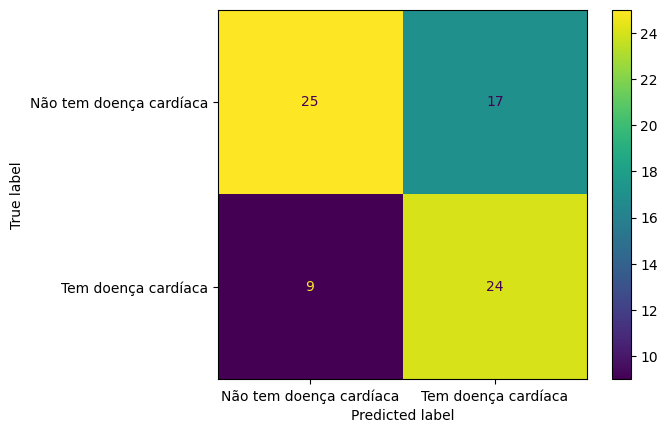

In [23]:
# Criar e exibir a matriz de confusão usando o modelo treinado
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test, display_labels=["Não tem doença cardíaca", "Tem doença cardíaca"])

Na matriz de confusão, vemos que, das **25 + 17 = 42** pessoas que não tinham **doença cardíaca**, **25 (59%)** foram classificadas corretamente. E das **9 + 24 = 33** pessoas que tinham **doença cardíaca**, **24 (73%)** foram classificadas corretamente. Algo que pode estar prejudicando essa **Árvore de Classificação** é que o modelo pode ter sofrido **sobreajuste** no conjunto de dados de treinamento. A poda, em teoria, deve resolver esse problema e nos dar melhores resultados.

# Poda por complexidade de custo: visualizar alfa

A poda de uma árvore de decisão consiste em encontrar o valor correto para o parâmetro de poda, `alpha`, que controla o grau de poda. Uma maneira de encontrar o valor ideal para `alpha` é traçar a precisão da árvore em função de diferentes valores para `alpha`. Faremos isso tanto para o **Conjunto de Dados de Treinamento** quanto para o **Conjunto de Dados de Teste**.  
Primeiro, vamos extrair os diferentes valores de `alpha` disponíveis para esta árvore e construir uma árvore podada para cada valor de `alpha`. Omitimos o valor máximo para alpha porque ele podaria todas as folhas, deixando-nos apenas com uma raiz em vez de uma árvore, com o seguinte: `ccp_alphas = ccp_alphas[:-1]`.

In [24]:
path = clf_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas = ccp_alphas[:-1]

clf_dts = []
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf_dt.fit(X_train, y_train)
    clf_dts.append(clf_dt)

Vamos representar graficamente a precisão das árvores usando o conjunto de dados de treinamento e o conjunto de dados de teste em função de alfa.

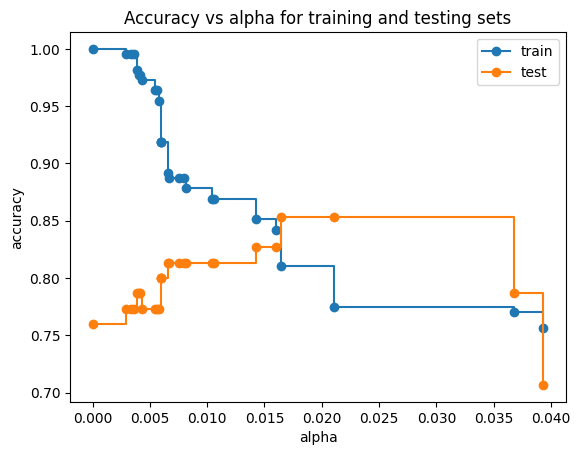

In [25]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.legend()
plt.show()

No gráfico acima, vemos que a precisão do **conjunto de dados de teste** atinge seu valor máximo quando `alpha` é de aproximadamente **0,016**. Após esse valor de `alpha`, a precisão do **donjunto de dados de treinamento** diminui, o que sugere que devemos definir `ccp_alpha=0,016`.

No entanto, como há muitas maneiras de dividir o conjunto de dados original em conjuntos de dados de **treinamento** e **teste**, como sabemos que usamos o melhor **conjunto de dados de treinamento** e como sabemos que usamos o melhor **conjunto de dados de teste**? Normalmente, respondemos a essa pergunta com a **validação cruzada**, por meio da função `cross_val_score()`.

# Validação cruzada para determinar o melhor alfa

Primeiro, vamos demonstrar que diferentes conjuntos de dados de treinamento e teste resultam em árvores com diferentes níveis de precisão:

<Axes: xlabel='tree'>

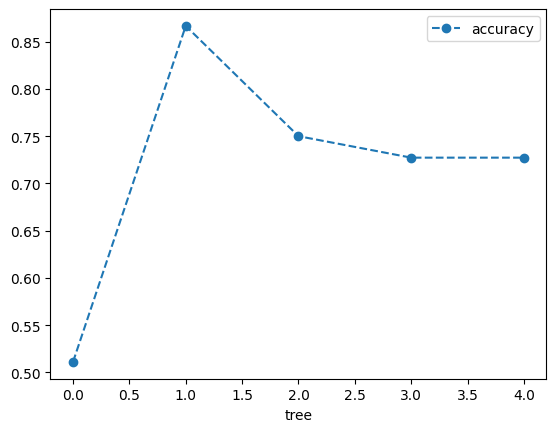

In [26]:
clf_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.016)
scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
df = pd.DataFrame(data={'tree': range(5), 'accuracy': scores})

df.plot(x='tree', y='accuracy', marker='o', linestyle='--')

Agora, vamos usar a validação cruzada para encontrar o valor ideal para ccp_alpha.

<Axes: xlabel='alpha'>

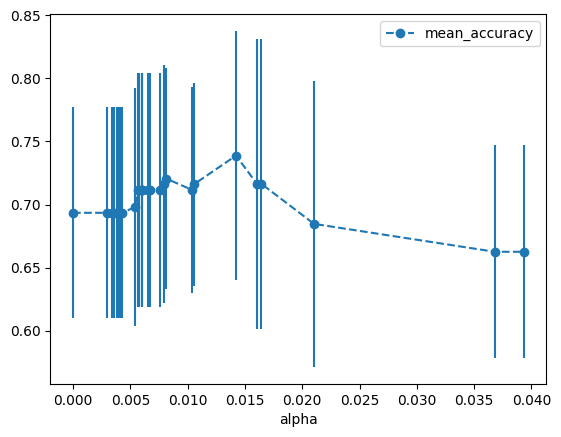

In [27]:
alpha_loop_values = []
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])
    
alpha_results = pd.DataFrame(alpha_loop_values, 
                             columns=['alpha', 'mean_accuracy', 'std'])

alpha_results.plot(x='alpha', 
                   y='mean_accuracy', 
                   yerr='std', 
                   marker='o', 
                   linestyle='--')

Usando a validação cruzada, podemos ver que, no geral, em vez de definir `ccp_alpha=0,016`, precisamos defini-lo para um valor mais próximo de **0,014**. Podemos encontrar o valor exato com:

In [28]:
ideal_ccp_alpha = alpha_results.loc[
    (alpha_results['alpha'] > 0.014) &
    (alpha_results['alpha'] < 0.015),
    'alpha'
]
ideal_ccp_alpha = float(ideal_ccp_alpha.iloc[0])
ideal_ccp_alpha


0.014224751066856332

# Construir, avaliar e representar a árvore de classificação final

In [29]:
# Construir a árvore de decisão podada usando o valor ideal de ccp_alpha encontrado
clf_dt_pruned = DecisionTreeClassifier(random_state=42, 
                                       ccp_alpha=ideal_ccp_alpha)
clf_dt_pruned = clf_dt_pruned.fit(X_train, y_train) 

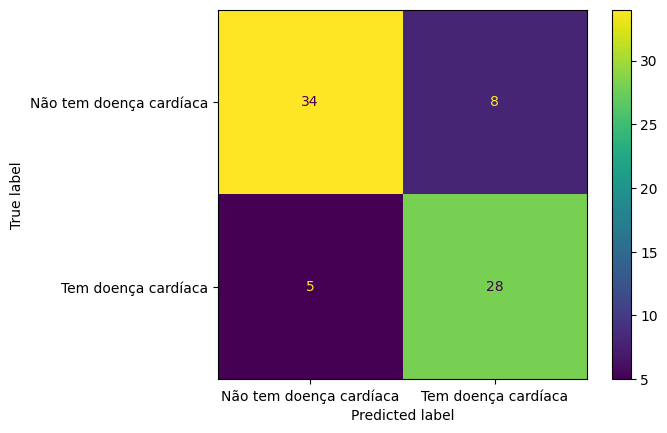

In [30]:
# Criar e exibir a matriz de confusão usando o modelo treinado
ConfusionMatrixDisplay.from_estimator(clf_dt_pruned,
                                      X_test,
                                      y_test,
                                      display_labels=["Não tem doença cardíaca", "Tem doença cardíaca"])

Das **34 + 8 = 42** pessoas que não tinham doença cardíaca, **34 (81%)** foram classificadas corretamente. Isso representa uma grande melhoria em relação à árvore completa, que classificou corretamente apenas **25 (59%)** dos pacientes sem doença cardíaca. Das **5 + 28 = 33** pessoas com doença cardíaca, **28 (85%)** foram classificadas corretamente. Mais uma vez, isso representa uma melhoria em relação à árvore completa, que classificou corretamente apenas **24 (73%)** dos pacientes com doença cardíaca.

[Text(0.5769230769230769, 0.875, 'ca <= 0.5\ngini = 0.498\nsamples = 222\nvalue = [118, 104]\nclass = Não tem doença cardíaca'),
 Text(0.3076923076923077, 0.625, 'thal <= 6.5\ngini = 0.382\nsamples = 132\nvalue = [98, 34]\nclass = Não tem doença cardíaca'),
 Text(0.4423076923076923, 0.75, 'True  '),
 Text(0.15384615384615385, 0.375, 'oldpeak <= 2.7\ngini = 0.24\nsamples = 93\nvalue = [80.0, 13.0]\nclass = Não tem doença cardíaca'),
 Text(0.07692307692307693, 0.125, 'gini = 0.185\nsamples = 87\nvalue = [78, 9]\nclass = Não tem doença cardíaca'),
 Text(0.23076923076923078, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [2, 4]\nclass = Tem doença cardíaca'),
 Text(0.46153846153846156, 0.375, 'cp <= 3.5\ngini = 0.497\nsamples = 39\nvalue = [18, 21]\nclass = Tem doença cardíaca'),
 Text(0.38461538461538464, 0.125, 'gini = 0.42\nsamples = 20\nvalue = [14, 6]\nclass = Não tem doença cardíaca'),
 Text(0.5384615384615384, 0.125, 'gini = 0.332\nsamples = 19\nvalue = [4, 15]\nclass = Tem doença cardí

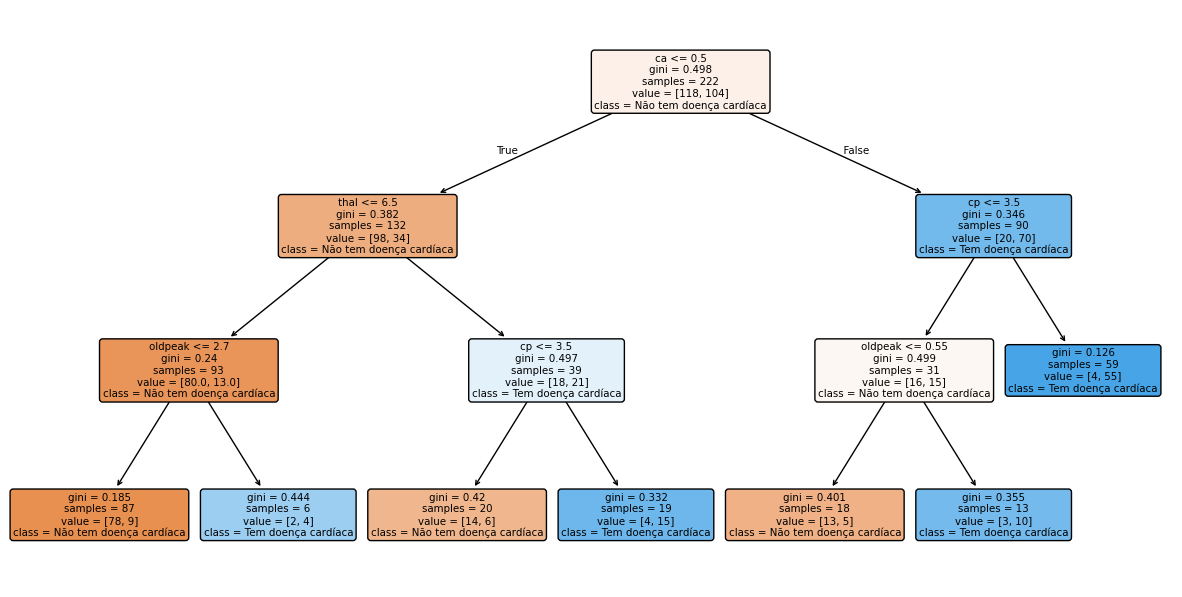

In [31]:
plt.figure(figsize=(15,7.5))
plot_tree(clf_dt_pruned, 
          filled=True, 
          rounded=True, 
          class_names=["Não tem doença cardíaca", "Tem doença cardíaca"], 
          feature_names=X.columns) 

Em cada nó, temos:
- A variável (nome da coluna) e o limiar para dividir as observações. Por exemplo, na raiz da árvore, usamos **ca** para dividir as observações. Todas as observações com **ca <= 0,5** vão para a **esquerda** e todas as observações com **ca > 0,5** vão para a **direita**.
- **gini** é o índice ou pontuação de Gini para esse nó
- **samples** nos diz quantas amostras há nesse nó
- **value** nos diz quantas amostras no nó estão em cada categoria. Neste exemplo, temos duas categorias, **Não** e **Sim**, referindo-se ao fato de um paciente ter ou não doença cardíaca. O número de pacientes com **Não** vem primeiro porque as categorias estão em ordem alfabética. Assim, na raiz, 118 pacientes têm **Não** e 104 pacientes têm **Sim**.
- **class** nos diz qual categoria é mais representada no nó. Na raiz, como 118 pessoas têm **Não** e apenas 104 pessoas têm **Sim**, a classe é definida como **Não**.

As folhas são exatamente como os nós, exceto que não contêm uma variável e um limiar para dividir as observações.

Os nós e as folhas são coloridos de acordo com a **class**. Neste caso, **Não** apresenta diferentes tons de laranja e **Sim** apresenta diferentes tons de azul. Quanto mais escuro o tom, menor a pontuação **gini**, e isso nos diz o quanto o nó ou a folha está inclinado(a) para uma classe.